In [1]:
import time

import numpy as np
import matplotlib.pylab as plt
import cv2 as cv
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = "cuda"

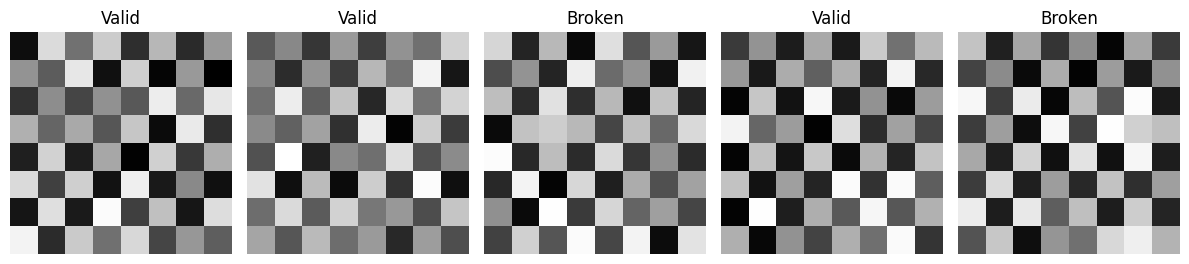

In [62]:
class CheckerboardDataset(Dataset):
    """
    PyTorch dataset generating:
    - Valid noisy checkerboards (label = 1)
    - Broken (phase-shifted) noisy checkerboards (label = 0)

    Noise is applied ONLY to intensities for both classes.
    Broken class may get slight structural corruption.
    """

    def __init__(
        self,
        num_samples=1000,
        size=8,
        noise_white=120,
        noise_black=120,
        bitflip_prob_broken=0.02,   # only for broken
    ):
        super().__init__()
        self.num_samples = num_samples
        self.size = size
        self.noise_white = noise_white
        self.noise_black = noise_black
        self.bitflip_prob_broken = bitflip_prob_broken

        self.images = []
        self.labels = []

        for _ in range(num_samples):

            label = np.random.randint(0, 2)   # FIXED: now 0 or 1


            x = np.indices((size, size))
            img = (x[0] % 2) ^ (x[1] % 2)
            if label == 0:
                img = 1 - img   # broken pattern

            img = img.astype(np.float32)

            if label == 0 and self.bitflip_prob_broken > 0:
                flip_mask = np.random.rand(size, size) < self.bitflip_prob_broken
                img[flip_mask] = 1 - img[flip_mask]

            img_255 = img * 255.0

            # noise for white squares
            white_mask = img == 1
            white_noise = np.random.randint(0, noise_white + 1, img.shape)
            img_255 -= white_noise * white_mask

            # # noise for black squares
            black_mask = img == 0
            black_noise = np.random.randint(0, noise_black + 1, img.shape)
            img_255 += black_noise * black_mask

            # final clipping and conversion
            img_255 = np.clip(img_255, 0, 255).astype(np.uint8)

            # ------------------------------
            # 5) Normalize to [0,1] tensor
            # ------------------------------
            img_tensor = torch.tensor(img_255, dtype=torch.float32).unsqueeze(0) / 255.0

            self.images.append(img_tensor)
            self.labels.append(torch.tensor([label], dtype=torch.float32))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]



dataset = CheckerboardDataset(num_samples=200, size=8)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

imgs, labels = next(iter(loader))

plt.figure(figsize=(12, 3))
for i in range(5):
    img = imgs[i].squeeze(0)
    label = int(labels[i].item())

    plt.subplot(1, 5, i + 1)
    img_np = img.squeeze().cpu().numpy().astype(np.float32) * 255
    plt.imshow(img_np, cmap='gray', vmin=0, vmax=255)
    
    plt.title("Valid" if label == 1 else "Broken")
    plt.axis("off")

plt.tight_layout()
plt.show()